# Hồi quy tuyến tính bội

Lấy dữ liệu đã làm sạch:

In [153]:
gpu_clean <- read.csv("gpu_ready_for_models.csv")

Cài đặt thư viện

In [154]:
install.packages("GGally")
install.packages("car")
install.packages("lmtest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Mục tiêu của phần này là xây dựng một mô hình dự đoán Max_Power dựa trên dữ liệu đã làm sạch từ phần trước.

Bắt đầu bằng việc chọn lọc các biến để xây dựng mô hình, sau đó từng bước đánh giá, kiểm định các giả định về mô hình.

## 1. Xây dựng mô hình

Trước hết, mô hình sẽ bỏ qua các biến phân loại như `Manufacturer`, `Memory_Type` và `Notebook_GPU`.

In [155]:
cols_to_ignore = c("Manufacturer", "Memory_Type", "Notebook_GPU")
gpu_filter <- gpu_clean[, !(names(gpu_clean) %in% cols_to_ignore)]
names(gpu_filter)

[1] "Core_Speed"       "Max_Power"        "Memory"           "Memory_Bandwidth"
[5] "Memory_Speed"     "Memory_Bus"       "Process"          "ROPs"            
[9] "TMUs"

Ta sẽ đánh giá sơ bộ về dữ liệu dùng để dự báo, cụ thể cần để ý về mối quan hệ giữa biến mục tiêu với các biến dự báo, và giữa các biến dự báo với nhau. Ma trận sau đây có thể cho ta một cái nhìn tổng quát:

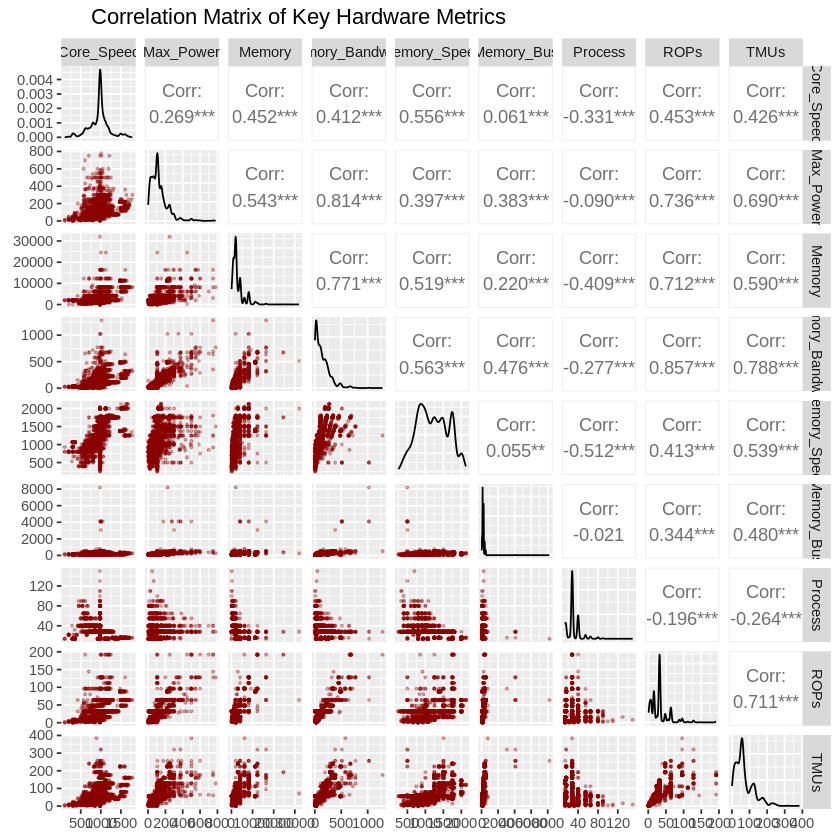

In [156]:
library(GGally)
p_pairs <- ggpairs(gpu_filter,
                   title = "     Correlation Matrix of Key Hardware Metrics",
                   lower = list(continuous = wrap("points", alpha = 0.3, size = 0.5, color = "darkred")))
p_pairs

Có thể thấy rằng:

Thứ nhất, quan hệ giữa Max_Power và các biến dự báo không tuyến tính một cách rõ ràng, thay vào đó các điểm dữ liệu có xu hướng toả rộng ra. Điều này gợi ý rằng một số giả định ban đầu về mô hình có thể bị vi phạm, ví dụ như tính tuyến tính, hoặc phân phối chuẩn của sai số.

Thứ hai, độ tương quan giữa Max_Power và các biến đều tương đối tốt, tuy nhiên độ tương quan giữa các biến với nhau cũng vậy, ví dụ như biến dự báo Memory_Bandwidth có tương quan khá cao với nhiều biến dự báo còn lại. Gợi ý rằng mô hình có thể gặp hiện tượng đa cộng tuyến.

Các phần sau sẽ phân tích sâu hơn và xử lý các yếu tố này. Bây giờ ta sẽ phân chia dữ liệu thành 2 tập train và test với tỉ lệ 8:2 và xây dựng mô hình:

In [157]:

set.seed(42)
n <- nrow(gpu_filter)
train_size <- floor(0.8 * n)
train_indices <- sample(seq_len(n), size = train_size)

# Tách dữ liệu
train_set <- gpu_filter[train_indices, ]
test_set  <- gpu_filter[-train_indices, ]
cat("Train set:", nrow(train_set), "dòng\n")
cat("Test set:", nrow(test_set), "dòng")

base_model <- lm(Max_Power ~ ., data = train_set)
summary(base_model)

Train set: 2543 dòng
Test set: 636 dòng


Call:
lm(formula = Max_Power ~ ., data = train_set)

Residuals:
    Min      1Q  Median      3Q     Max 
-372.67  -26.66   -1.97   24.19  416.64 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)      47.2262543  6.6889359   7.060 2.14e-12 ***
Core_Speed       -0.0295946  0.0054540  -5.426 6.30e-08 ***
Memory           -0.0069972  0.0006571 -10.649  < 2e-16 ***
Memory_Bandwidth  0.6006680  0.0215599  27.860  < 2e-16 ***
Memory_Speed     -0.0082301  0.0038257  -2.151   0.0315 *  
Memory_Bus       -0.0276994  0.0049574  -5.587 2.55e-08 ***
Process           0.6754481  0.0967072   6.984 3.64e-12 ***
ROPs              0.6129215  0.0844617   7.257 5.24e-13 ***
TMUs              0.2445982  0.0352766   6.934 5.18e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 50.84 on 2534 degrees of freedom
Multiple R-squared:  0.716,	Adjusted R-squared:  0.7151 
F-statistic: 798.6 on 8 and 2534 DF,  p-value: < 2.2e-1

Đầu tiên ta sẽ tiến hành đánh giá mức độ của hiện tượng đa cộng tuyến thông qua chỉ số VIF của từng biến độc lập sử dụng lệnh vif() từ thư viện `car`:

In [158]:
library(car)
vif(base_model)

Core_Speed           Memory Memory_Bandwidth     Memory_Speed 
        1.688765         3.017898         8.026167         2.572462 
      Memory_Bus          Process             ROPs             TMUs 
        1.603797         1.466698         4.579368         3.099710

Kết quả của lệnh trên cho thấy biến Memory_Bandwidth có VIF > 5, ta sẽ thử loại biến khỏi mô hình và đánh giá mô hình mới (`model_1`):

In [159]:
model_1 <- lm(Max_Power ~ . - Memory_Bandwidth, data = train_set)
vif(model_1)

Core_Speed       Memory Memory_Speed   Memory_Bus      Process         ROPs 
    1.599909     2.449114     2.145062     1.377115     1.448263     2.901388 
        TMUs 
    2.882764

Các biến dự báo của mô hình lúc này đã đều có VIF < 5. Ta tiến hành so sánh 2 mô hình `model_1` (mới) và `base_model` (cũ) sử dụng t-test để kiểm định hệ số hồi quy $\beta_4$ với mức ý nghĩa 5%:
- $H_0: \beta_4 = 0$
- $H_1: \beta_4 ≠ 0$

Kết quả của kiểm định này có thể được gọi ra từ lệnh `summary(base_model)`:

In [160]:
summary(base_model)$coefficients["Memory_Bandwidth",]

Estimate    Std. Error       t value      Pr(>|t|) 
 6.006680e-01  2.155990e-02  2.786043e+01 3.030042e-149

Cụ thể kết quả này được hiển thị ở cột Pr(>|t|). Có thể thấy rằng, kiểm định trên cho kết quả p-value vô cùng thấp so với mức ý nghĩa, ta có thể bác bỏ $H_0$.

Kiểm định trên cho ta thấy rằng mặc dù Memory_Bandwidth nó có độ tương quan cao với các biến khác, biến này vẫn có ý nghĩa hồi quy đối với mô hình. Do đó ta chấp nhận base_model và tiếp tục tới bước kiểm định hệ số hồi quy của tất cả các biến còn laị với mức ý nghĩa 5%, sử dụng t-test:
- $H_0: \beta_i = 0$
- $H_1: \beta_i ≠ 0$

Tương tự như t-test phía trên, ta sử dụng hàm summary():

In [161]:
summary(base_model)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),47.226254314,6.6889359203,7.060354,2.136002e-12
Core_Speed,-0.029594611,0.0054540180,-5.426203,6.302259e-08
Memory,-0.006997151,0.0006570812,-10.648838,6.185993e-26
Memory_Bandwidth,0.600667984,0.0215598967,27.860430,3.030042e-149
Memory_Speed,-0.008230145,0.0038256636,-2.151299,3.154690e-02
Memory_Bus,-0.027699375,0.0049574225,-5.587455,2.550171e-08
Process,0.675448086,0.0967072107,6.984465,3.639655e-12
ROPs,0.612921454,0.0844617053,7.256797,5.244745e-13
TMUs,0.244598245,0.0352766359,6.933718,5.182552e-12


Dựa vào kết quả của lệnh trên, ta nhận ra ngay có p-value của kiểm định dành cho Memory_Speed cao hơn mức ý nghĩa. Như vậy, ta chưa bác bỏ giả thuyết Không của biến hồi quy Memory_Speed.

Ta loại biến Memory_Speed ra khỏi mô hình và kiểm tra một lần nữa:

In [162]:
model_2 <- lm(Max_Power ~ . - Memory_Speed, data = train_set)
summary(model_2)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),40.306863686,5.8690715291,6.867673,8.179154e-12
Core_Speed,-0.034064338,0.0050463768,-6.750257,1.822827e-11
Memory,-0.006919561,0.0006565599,-10.539116,1.900423e-25
Memory_Bandwidth,0.581762408,0.0197016553,29.528606,5.830022e-165
Memory_Bus,-0.024434000,0.0047227118,-5.173722,2.474331e-07
Process,0.747956829,0.0907085494,8.245715,2.603425e-16
ROPs,0.671468661,0.0800142671,8.391862,7.840713e-17
TMUs,0.229499371,0.0345961318,6.633671,3.988619e-11


Lần này thì mọi biến hồi quy đều đã có p-value cao hơn mức ý nghĩa, ta có thể nhận mô hình này làm mô hình chính.

$Max\_Power$

$=\beta_0+\beta_1*Core\_Speed+\beta_2*Memory+\beta_3*Memory\_Bandwidth$

$+\beta_4*Memory\_Bus+\beta_5*Process+\beta_6*ROPs+\beta_7*TMUs$

In [163]:
main_model <- model_2
main_model


Call:
lm(formula = Max_Power ~ . - Memory_Speed, data = train_set)

Coefficients:
     (Intercept)        Core_Speed            Memory  Memory_Bandwidth  
        40.30686          -0.03406          -0.00692           0.58176  
      Memory_Bus           Process              ROPs              TMUs  
        -0.02443           0.74796           0.67147           0.22950  


Ta có ước lượng của các hệ hồi quy:

$\beta_0$: 40.823021
$\beta_1$: -0.033872
$\beta_2$: -0.006837
$\beta_3$: 0.548696

$\beta_4$: -0.030331
$\beta_5$: 0.721248
$\beta_6$: 0.716958
$\beta_7$: 0.290304



## 2. Chẩn đoán mô hình
#### 2.1. Kiểm tra các giả định
- Tính tuyến tính của mô hình.
- Sai số ngẫu nhiên là độc lập.
- Sai số ngẫu nhiên có phân phối $N(0, \sigma^2)$
- Sai số ngẫu nhiên có phương sai không đổi.
- Không có sai số khi đo lường giá trị của các biến dự báo.

Ở đây ta sẽ xem như không có sai sót trong quá trình thu thập dữ liệu, nghĩa là giả định cuối đã thoả mãn.

Trước tiên, ta có thể đánh giá sơ bộ về tính tuyến tính và phương sai hằng qua biểu đồ Residual vs Fitted

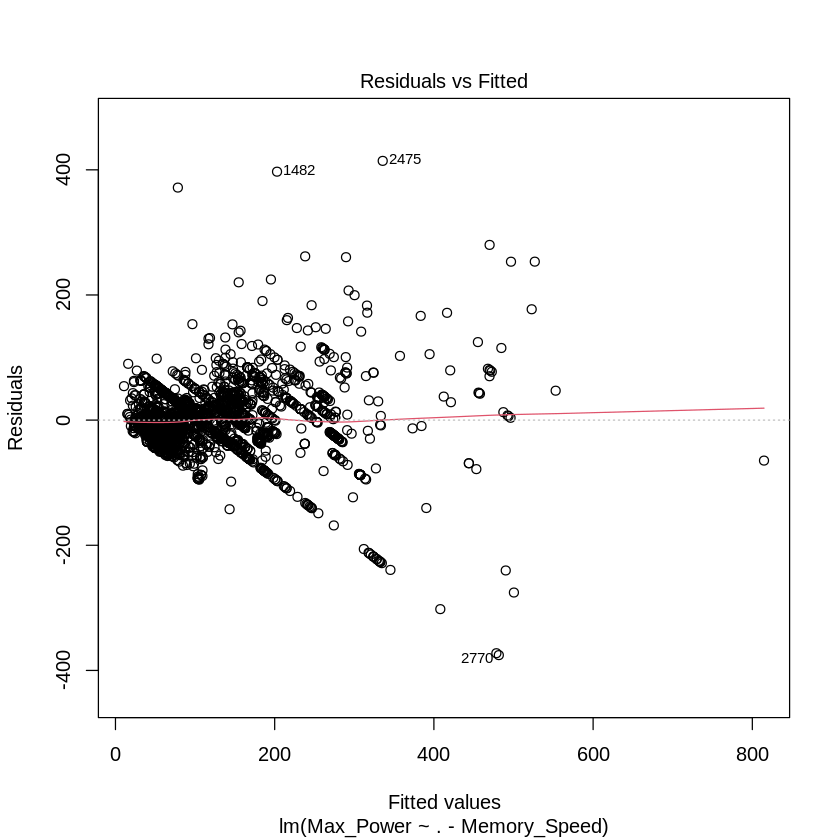

In [164]:
plot(main_model, which = 1)

Tính tuyến tính của mô hình có thể được chấp nhận khi trung bình của phần dư tại mỗi giá trị dự đoán - được thể hiện bởi đường màu đỏ - xấp xỉ 0. Ở biểu đồ này, đường màu đỏ cho ta thấy trung bình của các phần dư tương đối ổn định xung quanh đường y = 0 và có xu hướng hơi lệch ra xa y = 0 khi giá trị dự báo tăng lên, các điểm dữ liệu cũng thưa dần. Điều này gợi ý rằng sự chênh lệch này là không quá đáng kể và chủ yếu là do thiếu dữ liệu ở các giá trị dự báo lớn, do đó ta xem như giả định tuyến tính được thoả.

Giả định về phương sai hằng của sai số cũng có thể được đánh giá qua biểu đồ này. Có thể nhận thấy rằng khi các giá trị dự báo tăng lên, phân bố của các giá trị phần dư có xu hướng loe rộng ra (hình cái phễu). Điều này làm cho mô hình bị vi phạm giả định về phương sai hằng. Ta có thể kiểm tra kỹ hơn giả định về phương sai hằng bằng kiểm định Breusch-Pagan:

- $H_0$: các sai số có phương sai hằng.
- $H_1$: các sai số có phương sai thay đổi.

In [165]:
library(lmtest)
bptest(main_model)


	studentized Breusch-Pagan test

data:  main_model
BP = 591.45, df = 7, p-value < 2.2e-16


Với mức ý nghĩa 5%, ta có thể bác bỏ $H_0$, phù hợp với nhận định trước đó khi đánh giá biểu đồ Residual vs Fitted.

Tiếp theo, để kiểm tra giả định về phân phối chuẩn của sai số với giá trị kỳ vọng bằng 0, ta có thể đánh giá biểu đồ quantile-quantile (Q-Q plot), nếu các điểm dữ liệu nằm sát đường nét đứt, giả định về phân phối chuẩn của sai số có thể xem như thoả mãn:

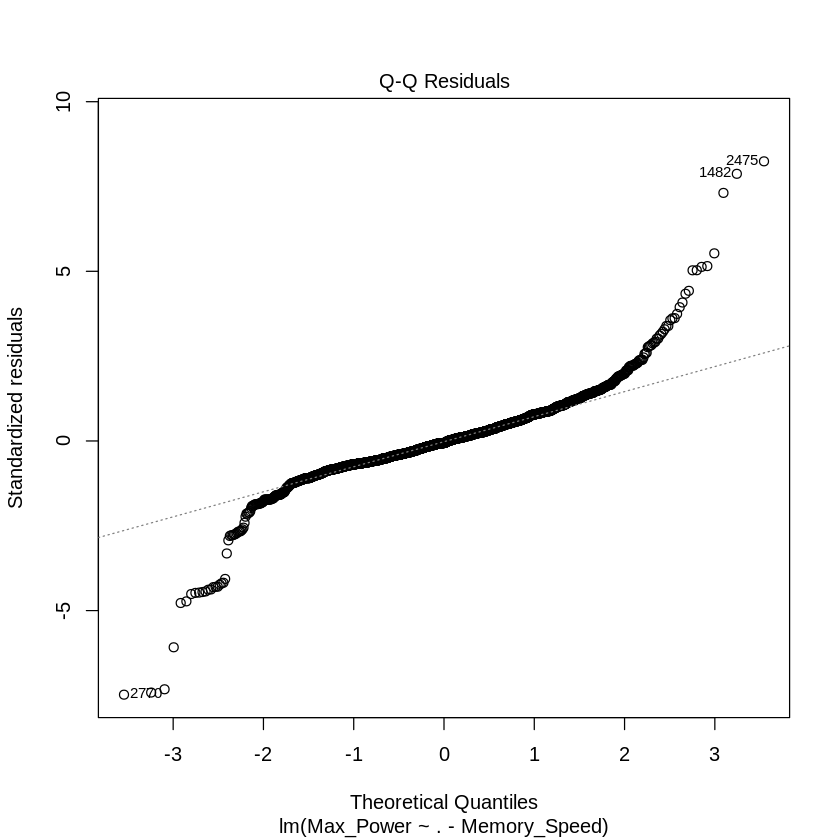

In [166]:
plot(main_model, which = 2)

Ở biểu đồ này, các điểm dữ liệu trong khoảng $Z_{score}$ từ -2 đến 2 đều nằm sát đường nét đứt, tuy nhiên khi đi về 2 phía theo trục x, các điểm dữ liệu càng đi xa đường nét đứt, và đối xứng qua đường nét đứt.
Điều này thể hiện rằng, mật độ giá trị sai số giao động gần giá trị 0 cao hơn so với theo phân phối chuẩn, khiến cho phân phối của sai số có dạng chuông nhọn, đuôi nặng.

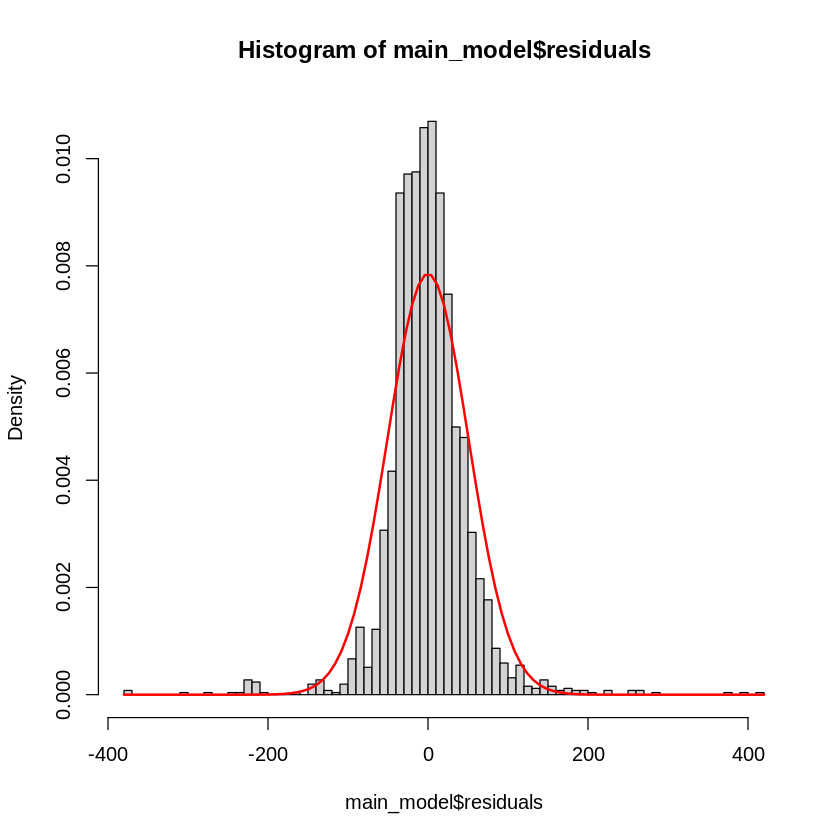

In [167]:
hist(main_model$residuals, breaks = 80, freq = FALSE)
m <- mean(main_model$residuals)
std <- sd(main_model$residuals)
curve(dnorm(x, mean = m, sd = std), col = "red", lwd = 2, add = TRUE)

Đến đây, ta dường như đã có thể kết luận rằng giả định về phân phối chuẩn cũng đã bị vi phạm. Tuy nhiên ta có thể kiểm tra một cách chính quy hơn bằng kiểm định Shapiro-Wilk:
- $H_0$: phân phối của sai số là phân phối chuẩn.
- $H_1$: phân phối của sai số không tuân theo phân phối chuẩn.

In [168]:
set.seed(42)
shapiro.test(main_model$residuals)


	Shapiro-Wilk normality test

data:  main_model$residuals
W = 0.88196, p-value < 2.2e-16


Với mức ý nghĩa 5%, kiểm định trên cũng bác bỏ $H_0$. Phù hợp với nhận định của ta khi đánh giá Q-Q plot.

## 3. Đánh giá mô hình
Mặc dù mô hình vi phạm một số giả định cơ bản về hồi quy tuyến tính, ta vẫn sẽ tiến hành đánh giá độ phù hợp của mô hình trên tập train và khả năng dự báo của mô hình trên tập test.

Đầu tiên là về độ phù hợp của mô hình trên tập train:

In [169]:
summary(main_model)


Call:
lm(formula = Max_Power ~ . - Memory_Speed, data = train_set)

Residuals:
    Min      1Q  Median      3Q     Max 
-375.55  -26.39   -3.14   24.20  414.30 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)      40.3068637  5.8690715   6.868 8.18e-12 ***
Core_Speed       -0.0340643  0.0050464  -6.750 1.82e-11 ***
Memory           -0.0069196  0.0006566 -10.539  < 2e-16 ***
Memory_Bandwidth  0.5817624  0.0197017  29.529  < 2e-16 ***
Memory_Bus       -0.0244340  0.0047227  -5.174 2.47e-07 ***
Process           0.7479568  0.0907085   8.246 2.60e-16 ***
ROPs              0.6714687  0.0800143   8.392  < 2e-16 ***
TMUs              0.2294994  0.0345961   6.634 3.99e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 50.88 on 2535 degrees of freedom
Multiple R-squared:  0.7155,	Adjusted R-squared:  0.7147 
F-statistic: 910.7 on 7 and 2535 DF,  p-value: < 2.2e-16


- Sai số chuẩn của phần dư (Residual standard error): $\sigma = 50.88$ trên 2535 bậc tự do. Ước lượng của mô hình lệch khoảng 50.88W so với thực tế.
- Hệ số xác định (Multiple R-squared): 0.7155. Các biến đầu vào giải thích được khoảng 71.55% dữ liệu của tập train.
- Kiểm định hồi quy (F-statistics):
  - $H_0$: $\beta_1 = \beta_2 = ... = \beta_7 = 0$
  - $H_1$: có ít nhất một hệ số $\beta_i ≠ 0$ với $ 1 ≤ i ≤ 7$

  Kết quả: $F = 910.7$, p-value = $2.2 \cdot 10^{-16}$

  Nếu ta chọn mức ý nghĩa 5%, kết quả trên đã bác bỏ giả thuyết Không, do đó kết luận mô hình có ý nghĩa hồi quy.

Tiếp theo ta tiến hành đánh giá khả năng dự báo của mô hình trên tập test, dùng RMSE (căn bậc hai của sai số bình phương trung bình).
$$RMSE = \sqrt{\frac{1}{n}\sum{(y_i - \hat{y}_i)^2}}$$
Nếu RMSE trên tập test của mô hình quá cao so với RMSE trên tập train, mô hình có thể gặp hiện tượng quá khớp (overfit). Ngoài ra ta còn có thể đánh giá hệ số xác định $R^2$.

In [173]:
predictions <- predict(main_model, newdata = test_set)
sse_train <- sum(main_model$residuals^2)
rmse_train <- sqrt(sse_train/nobs(main_model))
sse_test <- sum((test_set$Max_Power - predictions)^2)
rmse_test <- sqrt(sse_test/length(predictions))
cat("RMSE on train set = ", rmse_train)
cat("\nRMSE on test set = ", rmse_test)

sst <- sum((test_set$Max_Power - mean(test_set$Max_Power))^2)
r_squared <- 1 - sse_test/sst
cat("\nR-squared = ", r_squared)

RMSE on train set =  50.798
RMSE on test set =  54.07428
R-squared =  0.6875506

- RMSE trên tập train và test lần lượt xấp xỉ 50.80 và 54.07, chênh lệch không đáng kể do đó mô hình không bị overfit.
- $R^2 \approx 0.6876$: Mô hình giải thích được khoảng 68.76% biến thiên dữ liệu trên tập test, một kết quả tương đối cao.

Từ những kết quả trên có thể kết luận rằng mô hình không bị quá khớp và khả năng dự báo tốt.